# Portfolio Project: Life Expectancy and GDP Analysis

## Project Overview
This project explores the relationship between Gross Domestic Product (GDP) and life expectancy at birth across six nations: **Chile, China, Germany, Mexico, United States of America, and Zimbabwe**. The dataset is sourced from the World Health Organization (WHO) and the World Bank, spanning the years 2000 through 2015.

---

## 1. Project Goals
The primary objective is to investigate whether higher economic output shows up alongside higher life expectancy, and how that relationship manifests differently across distinct economic structures.

### Key Questions to Answer:
* **Trend Analysis:** Has life expectancy increased over time in each of the six nations?
* **Economic Trajectory:** Has GDP grown over time in each of the six nations?
* **Correlation:** Is there a strong statistical correlation between a nation's GDP and its life expectancy?
* **Comparative Distribution:** What is the average life expectancy for each nation, and how do distributions compare between high-GDP and low-GDP countries?

---

## 2. Dataset Overview
* **Source File:** `all_data.csv`
* **Features:**
  * `Country`: Categorical variable identifying the nation.
  * `Year`: Temporal variable ranging from 2000 to 2015.
  * `Life expectancy at birth (years)`: Continuous numerical target metric.
  * `GDP`: Continuous numerical economic output in USD.

---

## 3. Analytical Strategy
1. **Data Wrangling:** Load data, inspect for missing values, and standardize column names (e.g., rename `Life expectancy at birth (years)` to `LEABY`).
2. **Country Averages:** Compare mean life expectancy and mean GDP. Plot GDP in trillions of USD so the axis label matches the values.
3. **Time-Series Analysis:** Plot line charts to trace GDP and life expectancy trajectories over time per country.
4. **Correlation Analysis:** Report the Pearson correlation for each country, then construct scatter plots with regression trendlines faceted by country so large economies do not set the scale for every nation.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('all_data.csv')

# Inspect first few rows
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


## Step 1: Data Cleaning & Column Standardization
Rename the long column name `Life expectancy at birth (years)` to `LEABY` to simplify future function calls and data plotting.

In [2]:
# Rename long column name for easier reference
df.rename(columns={"Life expectancy at birth (years)": "LEABY"}, inplace=True)

# Inspect summary statistics and data structure
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  96 non-null     str    
 1   Year     96 non-null     int64  
 2   LEABY    96 non-null     float64
 3   GDP      96 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 3.1 KB
None
              Year      LEABY           GDP
count    96.000000  96.000000  9.600000e+01
mean   2007.500000  72.789583  3.880499e+12
std       4.633971  10.672882  5.197561e+12
min    2000.000000  44.300000  4.415703e+09
25%    2003.750000  74.475000  1.733018e+11
50%    2007.500000  76.750000  1.280220e+12
75%    2011.250000  78.900000  4.067510e+12
max    2015.000000  81.000000  1.810000e+13


### Key Takeaways:
* **Complete Dataset with No Missing Values:** There are exactly **96 entries** (rows) across 4 columns (`Country`, `Year`, `LEABY`, and `GDP`), with 96 non-null counts in every field. No data cleaning or imputation for missing values is required.
* **Granular Timeframe & Balanced Sample:** The dataset contains 16 consecutive years of data per country (from **2000 to 2015**), representing 6 distinct nations (6 x 16 = 96).
* **Wide Variance in Life Expectancy:** Across all observations, life expectancy ranges from a minimum of **44.3 years** to a maximum of **81.0 years**, with an overall average of **72.8 years**.
* **Significant Scale Disparities in GDP:** GDP spans from a minimum of **4.42 billion** (e.g., lower-income nations like Zimbabwe in earlier years) to a maximum of **18.1 trillion** (high-income nation like the US).

## Step 2: Average Life Expectancy and GDP by Country
Compare each country's average life expectancy and average GDP across 2000-2015. Averages show the level of each country. The line charts in Step 3 show how those levels changed year by year.

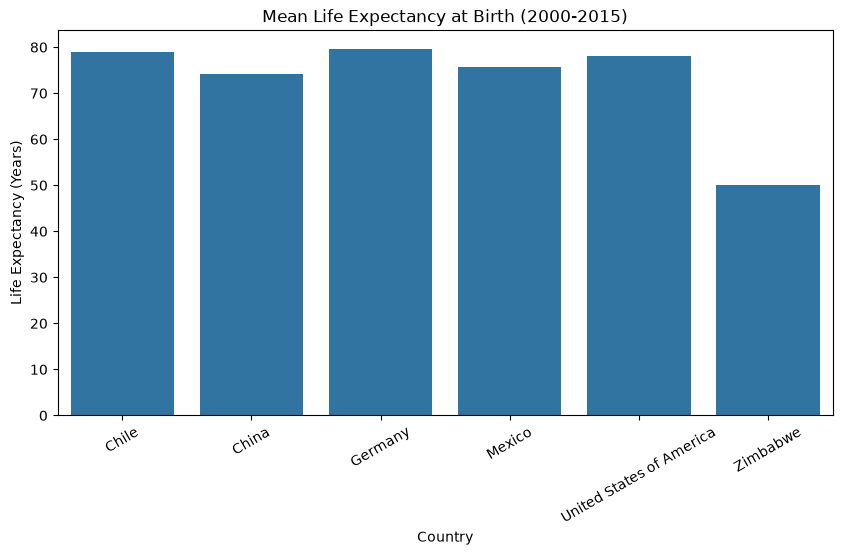

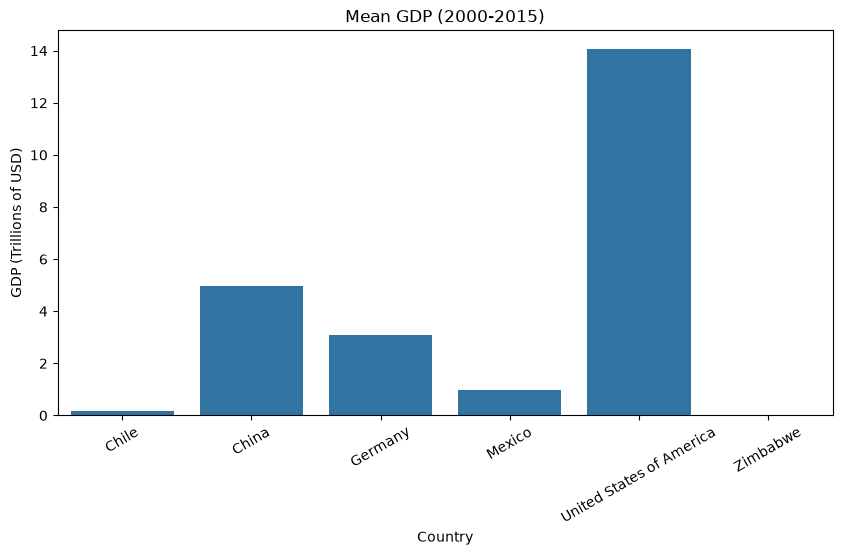

In [3]:
# Average life expectancy and GDP by country.
# GDP is stored in USD. Divide by 1e12 so the axis is labeled in trillions.
df_means = df.groupby("Country")[["LEABY", "GDP"]].mean().reset_index()
df_means["GDP_trillions"] = df_means["GDP"] / 1e12

plt.figure(figsize=(10, 5))
sns.barplot(data=df_means, x="Country", y="LEABY")
plt.title("Mean Life Expectancy at Birth (2000-2015)")
plt.ylabel("Life Expectancy (Years)")
plt.xticks(rotation=30)
plt.savefig("average_life_expectancy.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_means, x="Country", y="GDP_trillions")
plt.title("Mean GDP (2000-2015)")
plt.ylabel("GDP (Trillions of USD)")
plt.xticks(rotation=30)
plt.savefig("average_GDP.png", bbox_inches="tight")
plt.show()

### Key Takeaways:
* **High Baseline for Most Nations:** Five out of the six nations (Chile, China, Germany, Mexico, and the United States) have average life expectancies clustered tightly between **74 and 80 years**.
* **Zimbabwe is a Significant Outlier:** Zimbabwe's average life expectancy is drastically lower at approximately **50 years**, reflecting severe public health and socioeconomic challenges during the 2000-2015 timeframe.
* **Disproportionate GDP Distribution:** The United States (about **$14 trillion**) and China (about **$4.9 trillion**) have the largest average GDP. Germany is next at about **$3.1 trillion**. Mexico, Chile, and Zimbabwe are much smaller on a total-GDP basis. Total GDP mostly reflects the size of the economy, not output per person.
* **Similar Life Expectancy at Very Different Scale:** Chile's average life expectancy is comparable to the United States even though Chile's total GDP is much smaller. That comparison is about national totals, not GDP per person.

## Step 3: Change Over Time
The questions in the introduction ask whether life expectancy and GDP increased from 2000 to 2015. Country averages cannot answer that. Life expectancy shares a similar scale across countries, so one chart can show all six. GDP does not, so each country gets its own panel.

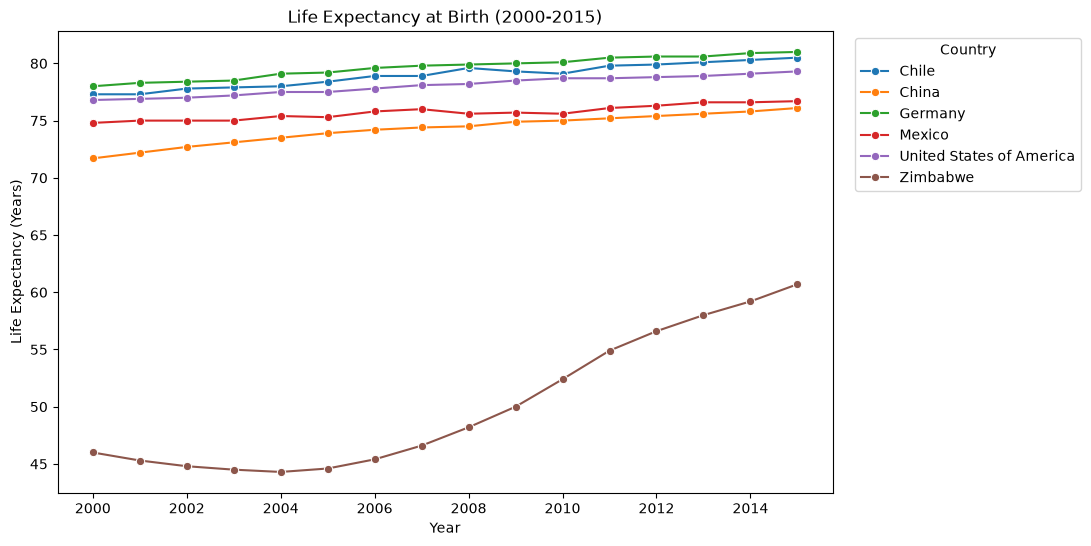

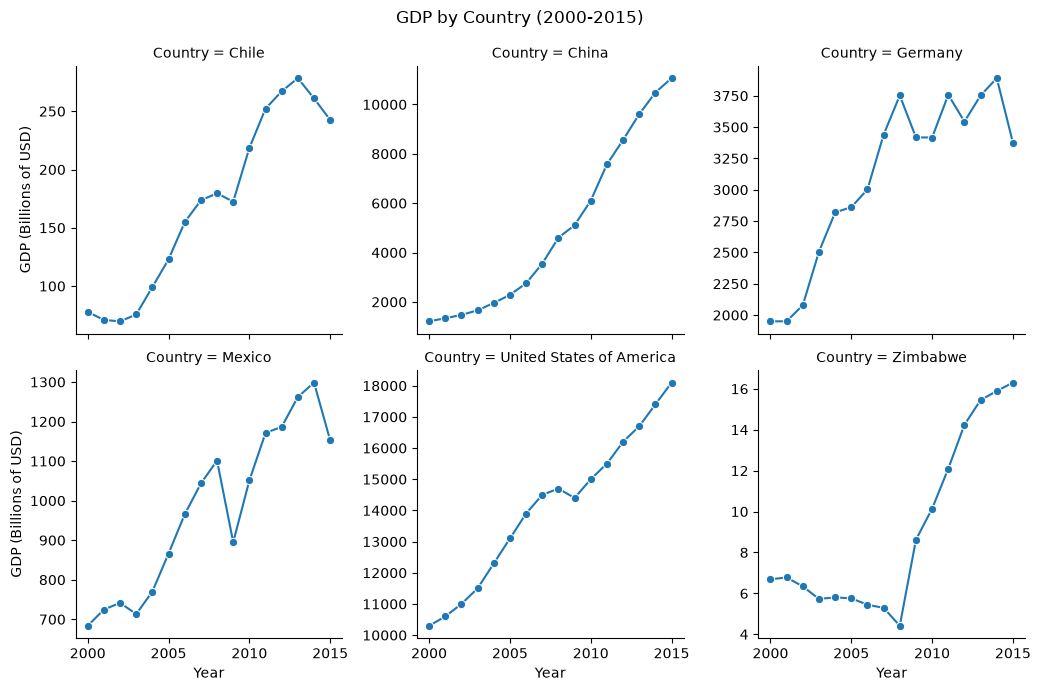

In [4]:
# Life expectancy uses a shared scale, so all six countries can share one chart.
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Year", y="LEABY", hue="Country", marker="o")
plt.title("Life Expectancy at Birth (2000-2015)")
plt.ylabel("Life Expectancy (Years)")
plt.xlabel("Year")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig("life_expectancy_over_time.png", bbox_inches="tight")
plt.show()

# National GDP spans several orders of magnitude. Separate panels keep each trend visible.
# Values are plotted in billions of USD.
gdp_by_year = df.copy()
gdp_by_year["GDP_billions"] = gdp_by_year["GDP"] / 1e9

g = sns.FacetGrid(gdp_by_year, col="Country", col_wrap=3, sharex=True, sharey=False, height=3.5)
g.map(sns.lineplot, "Year", "GDP_billions", marker="o")
g.set_axis_labels("Year", "GDP (Billions of USD)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("GDP by Country (2000-2015)")
plt.savefig("gdp_over_time.png", bbox_inches="tight")
plt.show()

### Key Takeaways:
* **Life Expectancy Ended Higher Everywhere:** Every country finished 2015 above its 2000 level. The path was not a straight line. Zimbabwe fell from **46.0** in 2000 to **44.3** in 2004, then climbed to **60.7** in 2015. Chile dipped from 2008 to 2010 before recovering.
* **GDP Ended Higher Everywhere Too:** China rose in every year in this file. Chile, Germany, Mexico, the United States, and Zimbabwe each had at least one year when GDP fell. On a shared axis the United States and China would hide the others, which is why GDP is split by country.
* **Zimbabwe's Turn Started Before GDP Recovered:** Life expectancy began rising in 2005. GDP did not bottom out until 2008.

## Step 4: GDP vs. Life Expectancy Correlation
Faceting by country avoids visual distortion caused by large differences in GDP scale between nations (for example, Zimbabwe and the United States). Each panel uses its own axes, so compare the pattern inside a country, not the steepness of the line across panels.

The table below is the Pearson correlation for each country. A value near 1 means the two columns move together. `LEABY vs Year` is included because both GDP and life expectancy rose over this period.

                 Country  LEABY vs GDP  LEABY vs Year  GDP vs Year
                   Chile         0.950          0.981        0.962
                   China         0.909          0.983        0.969
                 Germany         0.933          0.987        0.894
                  Mexico         0.932          0.950        0.937
United States of America         0.982          0.992        0.990
                Zimbabwe         0.966          0.924        0.838

All 96 rows together, LEABY vs GDP: 0.343
The overall number is much lower because countries sit on different GDP scales.


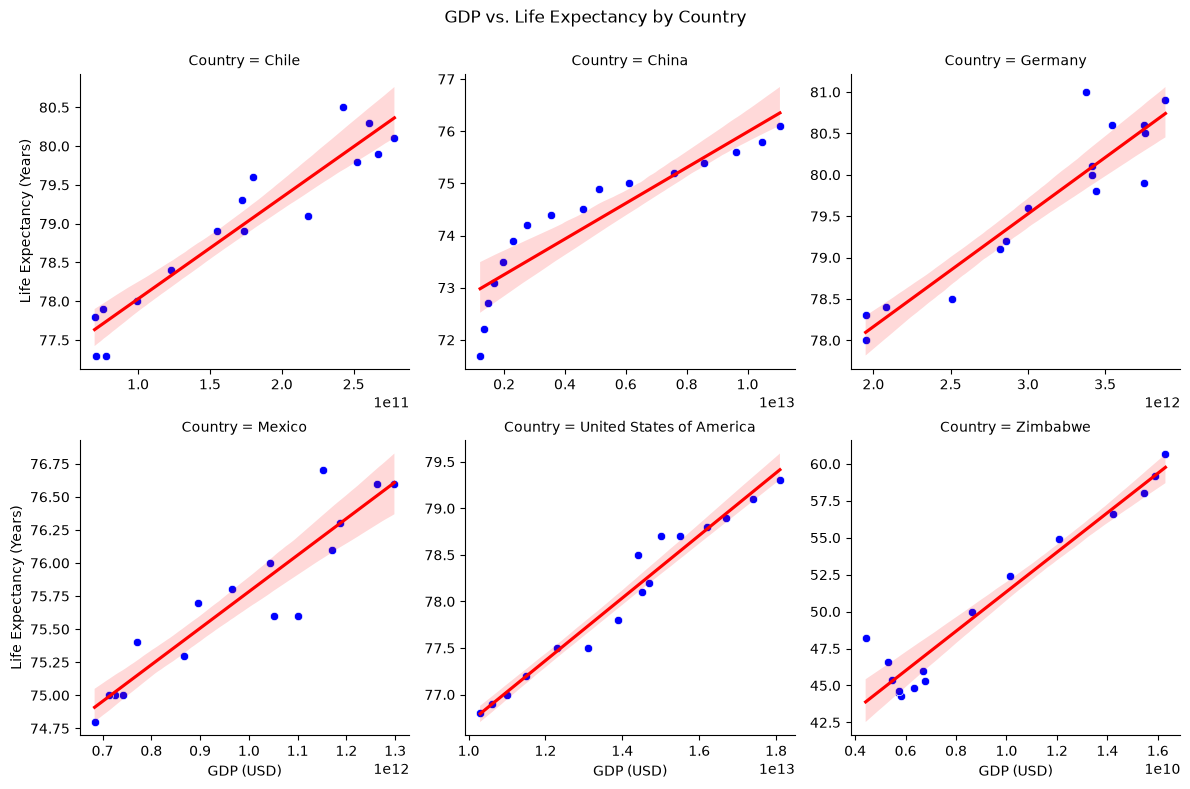

In [5]:
# One row per country: correlation of life expectancy with GDP and with calendar year.
corr_rows = []
for country, group in df.groupby("Country"):
    corr_rows.append(
        {
            "Country": country,
            "LEABY vs GDP": group["LEABY"].corr(group["GDP"]),
            "LEABY vs Year": group["LEABY"].corr(group["Year"]),
            "GDP vs Year": group["GDP"].corr(group["Year"]),
        }
    )
corr_df = pd.DataFrame(corr_rows)
print(corr_df.round(3).to_string(index=False))
print()
print("All 96 rows together, LEABY vs GDP:", round(df["LEABY"].corr(df["GDP"]), 3))
print("The overall number is much lower because countries sit on different GDP scales.")

# Faceted scatter plots isolate the within-country relationship.
g = sns.FacetGrid(df, col="Country", col_wrap=3, sharex=False, sharey=False, height=4)
g.map(sns.scatterplot, "GDP", "LEABY", color="b")
g.map(sns.regplot, "GDP", "LEABY", scatter=False, color="r")
g.set_axis_labels("GDP (USD)", "Life Expectancy (Years)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("GDP vs. Life Expectancy by Country")
plt.savefig("gdp_life_expectancy_by_country.png", bbox_inches="tight")
plt.show()

## Key Takeaways:
* **Positive Association in Every Nation:** Every country has a Pearson correlation between GDP and life expectancy of about **0.91 to 0.98**. For five of the six countries, life expectancy tracks the calendar year even more closely than it tracks GDP. Both series rose over the same years, so part of the scatter is a shared time trend. This is an association, not evidence that GDP alone caused the gains.
* **Zimbabwe's Path Is Not a Straight Climb:** Life expectancy fell from **46.0** in 2000 to **44.3** in 2004, then rose to **60.7** by 2015. GDP kept falling until **2008**, so the recovery in life expectancy started while the economy was still shrinking. Zimbabwe still gained about **15 years** over the full period, the largest gain in the dataset. Because each panel has its own GDP axis, a steeper line is not a larger gain per dollar.
* **Diminishing Returns in High-GDP Nations:** Highly developed economies like the United States and Germany show much flatter regression slopes on their own panels. In the US, life expectancy moved from about **76.8** to **79.3** years while GDP grew from about **$10 trillion** to **$18 trillion**. Once basic health infrastructure is established, later gains in years of life are smaller.
* **Country-Specific Clusters & Variations:**
  * **China & Chile:** Both display tight, steady upward trends, showing strong consistency between national economic growth and life expectancy gains.
  * **Mexico:** Exhibits a general positive trajectory, though with greater variance around the trendline compared to Chile or China. Mexico's life expectancy gain over the period is the smallest of the six, about **1.9 years**.

# Project Conclusions & Takeaways

## 1. Personal Learnings
Throughout this analysis, I learned that economic magnitude does not strictly dictate individual life expectancy. While the United States possesses a vast total GDP compared to many other nations in the dataset, several nations achieve nearly equal life expectancy outcomes. This underscores that factors beyond aggregate gross economic output  -  such as public health allocation, healthcare accessibility, and baseline social infrastructure  -  play critical roles in determining population longevity.

## 2. Surprising Findings
* **Parity Among Diverse Economies:** I was surprised to find that countries like **Chile, Mexico, and China** maintain life expectancies nearly equal to those of leading global economies like the **United States and Germany** (clustered between 74 and 80 years), despite operating at vastly different absolute GDP scales. Total GDP is a national total, so country size is part of that gap.
* **The Zimbabwe Outlier:** I was also struck by the vast disparity between **Zimbabwe** and all other countries in the dataset. Zimbabwe's average life expectancy hovered around 50 years during this period. Year by year, the story is a decline to 44.3 in 2004 and then a recovery to 60.7 in 2015. That recovery began before GDP reached its low point in 2008.

## 3. Key Findings & Core Takeaways
1. **Positive Association, With a Time Trend:** Every nation ended 2015 with higher life expectancy and higher GDP than in 2000. The within-country correlations are high. For most countries, life expectancy follows the year at least as closely as it follows GDP.
2. **Steep Public Health Returns in Developing Nations:** Zimbabwe experienced the largest gain in years of life. Early in the series, life expectancy and GDP did not move together: life expectancy was already rising while GDP was still falling.
3. **Diminishing Marginal Returns in Developed Nations:** High-GDP nations like the United States and Germany displayed smaller gains in years of life. Once basic infrastructure and healthcare systems are established, multi-trillion-dollar increases in GDP line up with smaller improvements in life expectancy.

## 4. Limits of This Comparison
Life expectancy is measured per person, while GDP in this file is the national total. A larger total often means a larger country, not a richer person. GDP per capita would be the next comparison to run, and it needs population data that is not in `all_data.csv`.

The charts support a positive association over 2000-2015. They do not, on their own, show that GDP caused the gains.

## Published Article & Summary

Read the full write-up and data visualization story on Medium:

[Beyond the Trillions: What GDP Can (and Can't) Tell Us About Global Life Expectancy](https://medium.com/@longm7718/diminishing-returns-health-disparities-a-data-visualization-study-of-global-gdp-and-life-e16fd45387f9)